### 패키지 로드

In [1]:
# ==================================================
# 수업용 유틸 / 사용자 정의 모듈
# ==================================================
from hossam import *

# ==================================================
# 데이터 처리
# ==================================================
import numpy as np
from pandas import DataFrame

# ==================================================
# 시각화
# ==================================================
import seaborn as sb
from matplotlib import pyplot as plt

# ==================================================
# sklearn - 파이프라인 / 전처리 / 모델 선택
# ==================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

# ==================================================
# sklearn - 성능 평가 지표
# ==================================================
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# ==================================================
# sklearn - KNN
# ==================================================
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance


### 데이터 가져오기 + 인덱스, 타입변환

In [7]:
origin=load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"]=origin["holiday"].astype("category")
origin["weekend"]=origin["weekend"].astype("category")
origin.info()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### 훈련,검증데이터 분리

In [12]:
df = origin

yname = "sales"
x=df.drop(columns=[yname])
y=df[yname]

x_train, x_test, y_train, y_test=train_test_split(
    x,y,test_size=0.25,random_state=52
)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((264, 8), (89, 8), (264,), (89,))

## KNN 모델 적합

### 모형 적합

In [14]:
%%time

# ----------------------------------
# 파이프라인 정의
# ----------------------------------
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor()),
    ]
)

# ----------------------------------
# 하이퍼파라미터 그리드
# ----------------------------------
param_grid = {
    # 핵심 파라미터 ⭐⭐⭐
    "model__n_neighbors": [3, 5, 7, 9, 15, 25],
    "model__weights": ["uniform", "distance"],

    # 거리 정의 ⭐⭐
    "model__metric": ["euclidean", "manhattan", "minkowski"],
    "model__p": [
        1,
        2,
    ],  # p=1: Manhattan, p=2: Euclidean (metric="minkowski"일 때만 의미 있음)

    # 탐색 알고리즘 / 성능 ⭐
    "model__algorithm": ["auto", "ball_tree", "kd_tree"],
    "model__leaf_size": [20, 30, 40],
}

# ----------------------------------
# GridSearchCV 설정
# ----------------------------------
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ----------------------------------
# 학습
# ----------------------------------
gs.fit(x_train, y_train)

# ----------------------------------
# 최적 모델
# ----------------------------------
best_model = gs.best_estimator_

# ----------------------------------
# 결과 확인
# ----------------------------------
print("Best params:", gs.best_params_)
print("CV best score:", gs.best_score_)


Best params: {'model__algorithm': 'auto', 'model__leaf_size': 20, 'model__metric': 'euclidean', 'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}
CV best score: 0.6444866391028172
CPU times: total: 1.3 s
Wall time: 5.02 s


📊 최적 하이퍼파라미터 (Best params)
- n_neighbors: 15 → 예측 시 15개의 가장 가까운 이웃을 참고
- weights: 'distance' → 가까운 이웃일수록 더 높은 가중치 부여
- metric: 'euclidean' → 유클리드 거리로 이웃 측정
- algorithm: 'auto' → 자동으로 최적 탐색 알고리즘 선택
- leaf_size: 20 → 트리 구조의 리프 노드 크기
- p: 1 → minkowski 거리의 p값 (사용 안 됨, metric이 euclidean이므로)

### 성능평가 지표

In [15]:
y_pred = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)

result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mse,
        "평균오차(RMSE)": np.sqrt(mse),
        "평균절대백분오차(MAPE)": mean_absolute_percentage_error(
            y_test,
            y_pred,
        ),
        "평균 비율 오차(MPE)": np.mean(
            (y_test - y_pred) / y_test * 100
        ),
    },
    index=["성능지표"],
)

result_df


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균절대백분오차(MAPE),평균 비율 오차(MPE)
성능지표,0.634869,0.178029,0.052234,0.228547,0.010843,0.301152


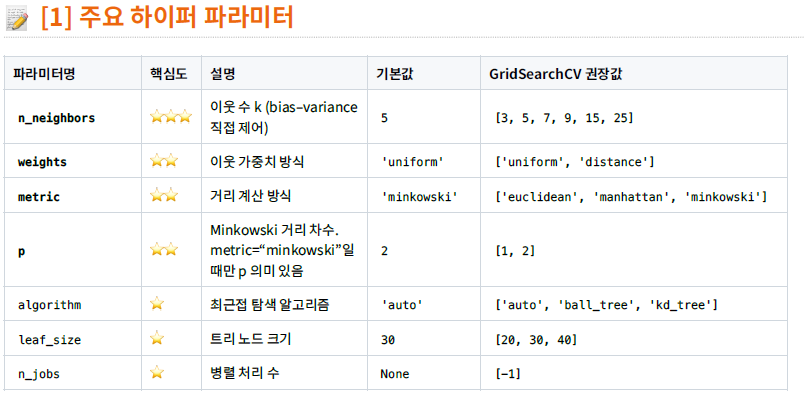<br>
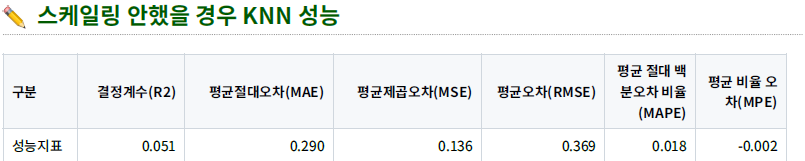